# Aggregators

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F94-Tools_aggregators.ipynb)

Aggregators are special type of nodes that includes a generic CPT for any numbers of parents.

*pyAgrum* proposes a list of such aggregators. Some of then are used below.

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

In [2]:
min_x = 0
max_x = 15

bn = gum.BayesNet()
l = [bn.add(gum.RangeVariable(item, item, min_x, max_x)) for item in ["a", "b", "c", "d", "e", "f"]]

gum.config["notebook", "histogram_line_threshold"] = 15

In [3]:
nmax = bn.addMAX(gum.RangeVariable("MAX", "MAX", min_x, max_x))
bn.addArc(l[0], nmax)
bn.addArc(l[1], nmax)
bn.addArc(l[2], nmax)

In [4]:
nmin = bn.addMIN(gum.RangeVariable("MIN", "MIN", min_x, max_x))
bn.addArc(l[3], nmin)
bn.addArc(l[4], nmin)
bn.addArc(l[5], nmin)

In [5]:
nampl = bn.addAMPLITUDE(gum.RangeVariable("DELTA", "DELTA", 0, max_x - min_x))
bn.addArc(nmax, nampl)
bn.addArc(nmin, nampl)

In [6]:
nmedian = bn.addMEDIAN(gum.RangeVariable("MEDIAN", "MEDIAN", min_x, max_x))
for n in [l[0], l[1], l[2], l[3]]:
  bn.addArc(n, nmedian)
# potential for median has a size : 16^5=2^20 double !

In [7]:
nexists = bn.addEXISTS(gum.LabelizedVariable("EXISTS_0", "EXISTS"), 0)
bn.addArc(l[0], nexists)
bn.addArc(l[1], nexists)
bn.addArc(l[2], nexists)

In [8]:
nforall = bn.addFORALL(gum.LabelizedVariable("FORALL_1", "FORALL"), 1)
bn.addArc(l[3], nforall)
bn.addArc(l[4], nforall)
bn.addArc(l[5], nforall)

In [9]:
ncount = bn.addCOUNT(gum.RangeVariable("COUNT_1", "COUNT_1,", 0, 3), 1)
bn.addArc(l[0], ncount)
bn.addArc(l[1], ncount)
bn.addArc(l[2], ncount)

In [10]:
for nod in l:
  bn.cpt(nod).fillWith(1).normalize()

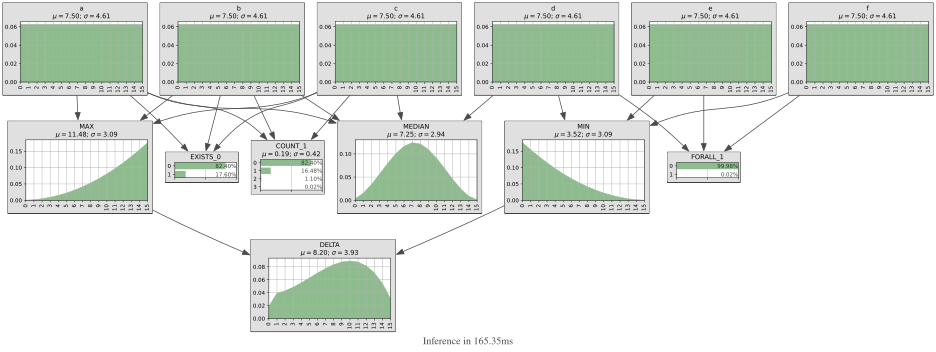

In [11]:
gnb.showInference(bn, size="13")

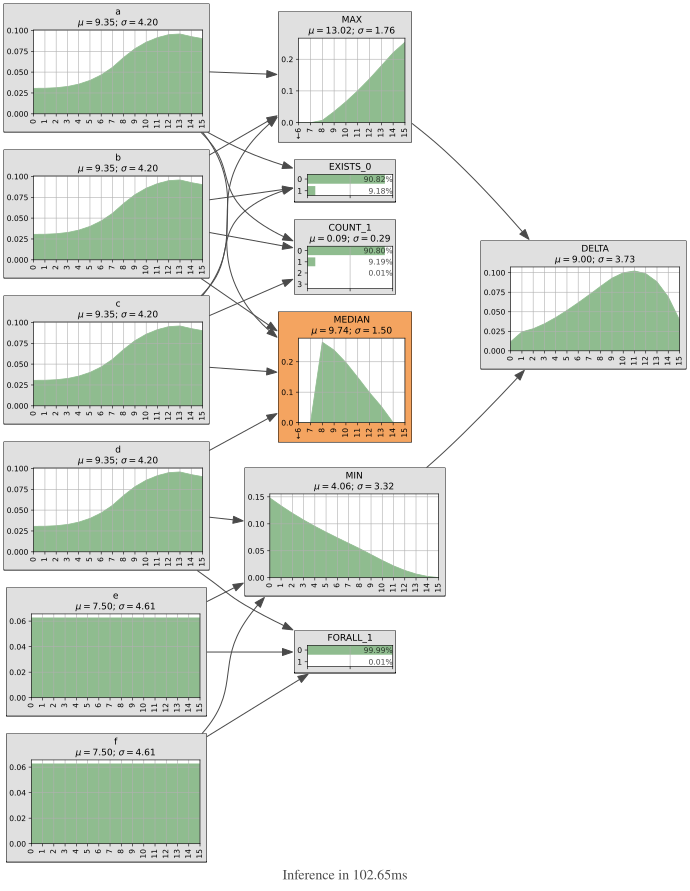

In [12]:
# dot | neato | fdp | sfdp | twopi | circo | osage | patchwork
gum.config["notebook", "graph_rankdir"] = "LR"
gnb.showInference(bn, size="13", evs={"MEDIAN": [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]})
gum.config.reset()

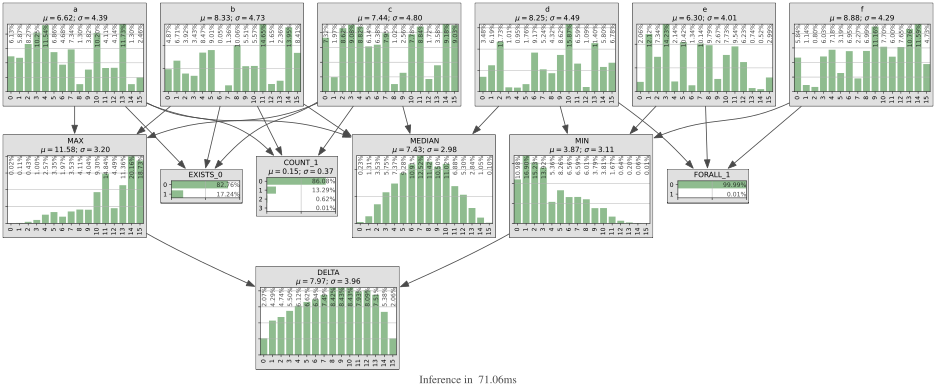

In [13]:
# if the roots do not have uniform but random distribution
for nod in l:
  bn.generateCPT(nod)

gnb.showInference(bn, size="13")

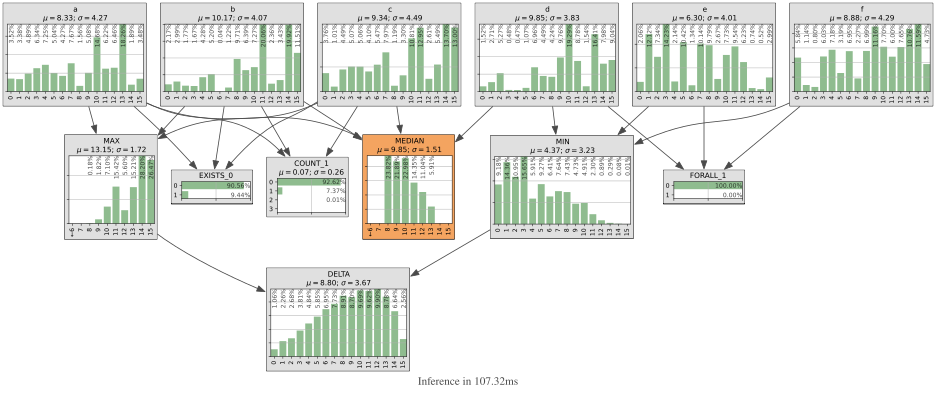

In [14]:
gnb.showInference(bn, size="13", evs={"MEDIAN": [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]})

## Input/Output

Aggregator (and ICI model) nodes have no stored CPT — the probability is computed on the fly from the aggregator's rule. Saving to most BN file formats (BIF, BIFXML, DSL, XDSL, net, UAI, O3PRM) **flattens** that computed table into a full dense CPT before writing it out. Round-tripping through one of these formats therefore loses the aggregator: reloading the file gives back a plain node with a dense CPT, not an aggregator (bad round trip).

Only aGrUM's native **jgum** (JSON) and **bgum** (binary) formats preserve the aggregator/ICI type exactly. Instead of a flat array of probabilities, the `cpt` entry for such a node is a small object describing its type and parameters, e.g. `{"kind": "aggregator", "name": "forall", "value": 1}` for a `FORALL` node, or `{"kind": "ici", "name": "MultiDimNoisyORCompound", ...}` for a Noisy-Or node.

In [15]:
import json
import os
import tempfile

demo = gum.BayesNet()
ps = [demo.add(gum.RangeVariable(f"P{i}", "", 0, 9)) for i in range(4)]
for i in range(4):
  demo.cpt(f"P{i}").randomCPT()
nsum = demo.addSUM(gum.RangeVariable("SUM", "", 0, 9))
for p in ps:
  demo.addArc(p, nsum)

with tempfile.TemporaryDirectory() as d:
  bif_path = os.path.join(d, "demo.bif")
  jgum_path = os.path.join(d, "demo.jgum")
  gum.saveBN(demo, bif_path)
  gum.saveBN(demo, jgum_path)
  bif_size = os.path.getsize(bif_path)
  jgum_size = os.path.getsize(jgum_path)
  with open(jgum_path) as f:
    jgum_content = json.load(f)

print(f"BIF  (dense CPT)         : {bif_size:>8} bytes")
print(f"jgum (compact aggregator): {jgum_size:>8} bytes")
print()
print(json.dumps(jgum_content, indent=2))

BIF  (dense CPT)         :   371373 bytes
jgum (compact aggregator):     1170 bytes

{
  "type": "BN",
  "GumJsonVersion": "1.0",
  "nodes": [
    "P0[10]",
    "P1[10]",
    "P2[10]",
    "P3[10]",
    "SUM[10]"
  ],
  "parents": {
    "P0": [],
    "P1": [],
    "P2": [],
    "P3": [],
    "SUM": [
      "P0",
      "P1",
      "P2",
      "P3"
    ]
  },
  "cpt": {
    "P0": [
      0.1523603567030006,
      0.10523506978832634,
      0.23939603520831226,
      0.05500421301332431,
      0.07183064389333227,
      0.018372603634743467,
      0.010277785162404629,
      0.052500511985939746,
      0.14841553372120142,
      0.14660724688941495
    ],
    "P1": [
      0.15016637294681834,
      0.20952088682533626,
      0.07395580717100375,
      0.1666812517598576,
      0.07711354408666404,
      0.12408291111561165,
      0.08283646957663882,
      0.10682395876693507,
      0.008142005279810793,
      0.0006767924713236839
    ],
    "P2": [
      0.08790932976700291,
      0.23

Indeed, the cpt for the node SUM should have a size of $10^4=10000$ floats. Instead :

In [16]:
print(json.dumps(jgum_content["cpt"]["SUM"], indent=2))

{
  "kind": "aggregator",
  "name": "sum"
}
